# Análisis de conectividad en la red del CENTIC con BFS

Este notebook modela la red del CENTIC como un grafo no dirigido y aplica BFS para determinar si existe una ruta válida entre un dispositivo de origen y el servidor central bajo restricciones de seguridad, ancho de banda y latencia.

## Información del proyecto

**Título:** Análisis de conectividad en la red del CENTIC de la UIS mediante teoría de grafos y el algoritmo BFS.

Este notebook acompaña el informe final del proyecto. Integra el planteamiento del problema, el modelo matemático, la implementación computacional, los escenarios de prueba, los resultados y las conclusiones.

## Integrantes y enlaces

**Integrantes**

- Adrian Santiago Sanchez Guerra - F2
- Daniel Joaquin Orjuela Holguin - F3
- Jose David Consuegra Medina - F3
- Cristian David Pinzón Galvis - F2

**Roles del grupo**

- Jose David Consuegra Medina: líder del grupo, desarrollo y redacción del informe final.
- Daniel Joaquin Orjuela Holguin: implementación del algoritmo BFS y apoyo en el notebook de Google Colab.
- Adrian Santiago Sanchez Guerra: apoyo en la elaboración del video.
- Cristian David Pinzón Galvis: apoyo en la elaboración del poster.

**Enlaces del proyecto**

- Notebook en Google Colab: https://colab.research.google.com/github/DanielJoaco/centic-bfs/blob/main/centic_bfs.ipynb
- Repositorio de GitHub: https://github.com/DanielJoaco/centic-bfs
- Video en YouTube: https://youtu.be/4uEC7MpZv7Q
- Poster: archivo adjunto en PDF externo.

## Descripción del problema

En una red institucional como la del CENTIC de la Universidad Industrial de Santander, distintos dispositivos necesitan comunicarse con un servidor central. Entre estos dispositivos se encuentran computadores de aulas, computadores centrales de aula, switches, routers Wi-Fi, cámaras, impresoras, computadores administrativos y equipos asociados a vigilancia.

El problema consiste en determinar si un dispositivo de origen puede alcanzar el servidor central a través de una ruta válida. Para que una ruta sea válida, cada conexión utilizada debe cumplir requisitos mínimos de seguridad, ancho de banda y latencia.

El grafo construido en este notebook es un modelo representativo y sintético inspirado en la red del CENTIC. No corresponde a una medición real exacta de la infraestructura, sino a una abstracción suficiente para estudiar conectividad bajo restricciones.

## Objetivos

**Objetivo general**

Modelar una red representativa del CENTIC de la UIS mediante un grafo no dirigido y analizar la existencia de rutas válidas hacia un servidor central usando BFS bajo restricciones de seguridad, ancho de banda y latencia.

**Objetivos específicos**

- Representar dispositivos de la red como vértices y conexiones físicas como aristas.
- Asociar a cada arista atributos de seguridad, ancho de banda y latencia.
- Definir escenarios de operación con distintos umbrales para validar conexiones.
- Implementar BFS de forma propia para buscar rutas hacia el servidor central.
- Comparar los resultados de alcanzabilidad en escenarios normal, seguridad alta, crítico y congestión.
- Analizar la utilidad del modelo de grafos para estudiar conectividad en redes institucionales.

In [28]:
# Librerías base para construir el grafo, recorrerlo y resumir resultados.
import random
from collections import deque
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Investigación del problema y alternativas de solución

El problema real se expresa como una consulta de alcanzabilidad: dado un origen, un destino y restricciones sobre los enlaces, se debe determinar si existe un camino hacia el servidor usando solamente conexiones válidas.

Alternativas consideradas:

- **BFS:** recorre el grafo por niveles desde el origen. Permite determinar alcanzabilidad y, en grafos no ponderados, encontrar una ruta con el menor número de saltos.
- **DFS:** también verifica conectividad, pero no garantiza una ruta con el menor número de saltos.
- **Componentes conexas:** permite responder muchas consultas de conectividad sobre un mismo subgrafo válido, pero describe menos directamente la ruta desde un origen específico.
- **Warshall o Floyd-Warshall:** permiten estudiar alcanzabilidad entre todos los pares de vértices, pero tienen mayor costo para este caso y son menos prácticos cuando solo se evalúan rutas hacia un servidor central.

Se selecciona BFS porque el proyecto busca conectividad y menor número de saltos dentro de un subgrafo filtrado por restricciones, no optimización por pesos acumulados. Dijkstra no se utiliza porque está prohibido por la guía del proyecto y no es necesario para este enfoque.

## Modelo del grafo

Sea $G=(V,E)$ un grafo no dirigido. Cada vértice representa un dispositivo de red o un equipo final. Cada arista representa una conexión física y tiene atributos $(s, b, l)$, donde $s$ es la seguridad, $b$ es el ancho de banda (Mbps) y $l$ es la latencia (ms).

La seguridad $s$ se modela en una escala ordinal de 1 a 5 con criterios operativos:

- 1: enlace sin segmentación ni cifrado; acceso abierto.
- 2: segmentación básica (VLAN), sin controles fuertes.
- 3: segmentación y autenticación básica, como 802.1X o credenciales, con monitoreo estándar.
- 4: segmentación y autenticación fuerte, con IDS/IPS o políticas estrictas.
- 5: enlace crítico con controles reforzados, como segmentación estricta, monitoreo continuo y acceso mínimo.

Por tanto, $s_{min}$ representa la seguridad mínima requerida en un escenario.

Una arista es válida si cumple $s \ge s_{min}$, $b \ge b_{min}$ y $l \le l_{max}$. El problema se reduce a encontrar un camino en el subgrafo formado por las aristas válidas.

In [20]:
# Fijamos la semilla para que la construcción y las figuras sean reproducibles.
random.seed(42)

## Escenarios y umbrales

Se consideran escenarios de operación con distintos umbrales:

- Normal: requisitos corporativos estándar sobre fibra.
- Seguridad alta: umbrales más estrictos para enlaces sensibles.
- Crítico: exige $s=5$ en todos los criterios, pensado para el servidor central o cámaras.
- Congestión: tolera mayor latencia y menor ancho de banda, con una exigencia de seguridad más flexible.

In [21]:
# Umbrales mínimos por escenario: seguridad, ancho de banda y latencia.
SCENARIOS = {
    "normal": {"s_min": 3, "b_min": 100, "l_max": 30},
    "seguridad_alta": {"s_min": 4, "b_min": 200, "l_max": 20},
    "critico": {"s_min": 5, "b_min": 300, "l_max": 15},
    "congestion": {"s_min": 2, "b_min": 50, "l_max": 50},
}

## Construcción del grafo

Se modelan 4 pisos, cada uno con 6 aulas: 5 normales con 15 PCs y 1 aula grande con 30 PCs. Cada aula tiene un PC central, una cámara y un router Wi-Fi. Además, cada piso cuenta con un puesto de recepción, una impresora y cámaras en el pasillo.

También se incluye un bloque administrativo y un cuarto de vigilancia. Todos los componentes se conectan al servidor central a través de un core switch.

In [22]:
def add_edge(G, u, v, security, bandwidth, latency):
    # Guardamos en cada arista los atributos que luego filtrará BFS.
    G.add_edge(u, v, security=security, bandwidth=bandwidth, latency=latency)


def build_centic_graph():
    # Se construye un grafo no dirigido con el servidor central como nodo raíz.
    G = nx.Graph()

    server = "server_central"
    core_switch = "core_switch"
    G.add_node(server, type="server")
    G.add_node(core_switch, type="core_switch")
    add_edge(G, server, core_switch, security=5, bandwidth=10000, latency=2)

    # Bloque administrativo y vigilancia, conectados al core con enlaces robustos.
    admin_switch = "admin_switch"
    surveillance_pc = "surveillance_pc"
    G.add_node(admin_switch, type="admin_switch")
    G.add_node(surveillance_pc, type="surveillance")
    add_edge(G, core_switch, admin_switch, security=5, bandwidth=1000, latency=5)
    add_edge(G, core_switch, surveillance_pc, security=5, bandwidth=1000, latency=5)

    admin_pcs = []
    for i in range(1, 6):
        pc = f"admin_pc_{i}"
        admin_pcs.append(pc)
        G.add_node(pc, type="admin_pc")
        add_edge(G, admin_switch, pc, security=5, bandwidth=500, latency=8)
    admin_printers = []
    for i in range(1, 3):
        pr = f"admin_printer_{i}"
        admin_printers.append(pr)
        G.add_node(pr, type="admin_printer")
        add_edge(G, admin_switch, pr, security=5, bandwidth=300, latency=10)

    # Cada piso replica la misma estructura básica para mantener el modelo uniforme.
    for floor in range(1, 5):
        floor_switch = f"floor{floor}_switch"
        receptionist_pc = f"floor{floor}_reception_pc"
        receptionist_printer = f"floor{floor}_reception_printer"

        G.add_node(floor_switch, type="floor_switch", floor=floor)
        G.add_node(receptionist_pc, type="reception_pc", floor=floor)
        G.add_node(receptionist_printer, type="reception_printer", floor=floor)

        add_edge(G, core_switch, floor_switch, security=5, bandwidth=1000, latency=5)
        add_edge(G, floor_switch, receptionist_pc, security=5, bandwidth=500, latency=8)
        add_edge(G, floor_switch, receptionist_printer, security=5, bandwidth=300, latency=10)

        # Cámaras de pasillo: enlaces moderados en seguridad y ancho de banda.
        for c in range(1, 4):
            cam = f"floor{floor}_corridor_cam_{c}"
            G.add_node(cam, type="camera", floor=floor)
            add_edge(G, floor_switch, cam, security=4, bandwidth=200, latency=15)

        # Aulas con switch propio, PC central, cámara, wifi y PCs de trabajo.
        for room in range(1, 7):
            room_tag = f"floor{floor}_room{room}"
            central_pc = f"{room_tag}_central_pc"
            cam = f"{room_tag}_cam"
            wifi_router = f"{room_tag}_wifi"
            room_switch = f"{room_tag}_switch"
            G.add_node(central_pc, type="room_central", floor=floor)
            G.add_node(cam, type="camera", floor=floor)
            G.add_node(wifi_router, type="wifi", floor=floor)
            G.add_node(room_switch, type="room_switch", floor=floor)

            add_edge(G, floor_switch, room_switch, security=4, bandwidth=1000, latency=8)
            add_edge(G, room_switch, central_pc, security=5, bandwidth=1000, latency=8)
            add_edge(G, room_switch, cam, security=4, bandwidth=200, latency=15)
            add_edge(G, room_switch, wifi_router, security=2, bandwidth=100, latency=25)

            # El aula 6 es más grande, por eso tiene más equipos.
            pc_count = 30 if room == 6 else 15
            for i in range(1, pc_count + 1):
                pc = f"{room_tag}_pc_{i}"
                G.add_node(pc, type="pc", floor=floor)
                add_edge(G, room_switch, pc, security=3, bandwidth=100, latency=20)

    return G

G = build_centic_graph()
len(G.nodes), len(G.edges)

(551, 550)

## Equivalencia entre el problema real y el problema matemático

La equivalencia central del proyecto es la siguiente:

- En la red real, se desea saber si un dispositivo puede comunicarse con el servidor central mediante conexiones aceptables.
- En el modelo matemático, se desea saber si existe un camino entre dos vértices dentro de un subgrafo de aristas válidas.

Cada escenario define umbrales mínimos. Una conexión que no cumple esos umbrales se descarta para el recorrido. Por tanto, BFS no se ejecuta sobre todo el grafo original de manera indiscriminada, sino sobre las conexiones que cumplen las condiciones requeridas al expandir vecinos.

## BFS con filtrado de aristas

Se implementa un BFS propio. La complejidad temporal es $O(|V|+|E|)$ y la espacial es $O(|V|)$. El filtrado de aristas se aplica durante la expansión de vecinos, de modo que solo se recorren enlaces que cumplen los umbrales definidos.

In [23]:
def edge_is_valid(data, s_min, b_min, l_max):
    # La arista solo se considera si cumple los tres umbrales al mismo tiempo.
    return (data["security"] >= s_min and
            data["bandwidth"] >= b_min and
            data["latency"] <= l_max)


def bfs_valid_path(G, source, target, s_min, b_min, l_max):
    # BFS clásico, pero expandiendo solo vecinos unidos por aristas válidas.
    visited = set([source])
    parent = {source: None}
    q = deque([source])

    while q:
        u = q.popleft()
        if u == target:
            break
        for v in G.neighbors(u):
            if v in visited:
                continue
            data = G.get_edge_data(u, v)
            if not edge_is_valid(data, s_min, b_min, l_max):
                continue
            visited.add(v)
            parent[v] = u
            q.append(v)

    if target not in parent:
        return None, len(visited)

    # Reconstruimos la ruta desde el destino hacia el origen.
    path = []
    cur = target
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, len(visited)

## Experimentos

Se prueban rutas desde distintos orígenes hacia el servidor central en cada escenario.

In [24]:
# Puntos de origen representativos para evaluar conectividad hacia el servidor.
server = "server_central"
origins = {
    "pc_aula": "floor2_room3_pc_5",
    "pc_central_aula": "floor1_room6_central_pc",
    "admin_pc": "admin_pc_2",
    "surveillance": "surveillance_pc",
}

results = []
for scen, th in SCENARIOS.items():
    # Probamos cada origen bajo los umbrales del escenario actual.
    for label, src in origins.items():
        path, visited = bfs_valid_path(G, src, server, **th)
        results.append({
            "scenario": scen,
            "origin": label,
            "reachable": path is not None,
            "path_length": None if path is None else len(path) - 1,
            "visited": visited,
        })

df_results = pd.DataFrame(results)
df_results

,scenario,origin,reachable,path_length,visited
0,normal,pc_aula,True,4.0,136
1,normal,pc_central_aula,True,4.0,136
2,normal,admin_pc,True,3.0,15
3,normal,surveillance,True,2.0,8
4,seguridad_alta,pc_aula,False,NaN,1
5,seguridad_alta,pc_central_aula,True,4.0,31
6,seguridad_alta,admin_pc,True,3.0,15
7,seguridad_alta,surveillance,True,2.0,8
8,critico,pc_aula,False,NaN,1
9,critico,pc_central_aula,False,NaN,2


## Visualización de topología

Se grafica un subgrafo representativo de un piso para mantener la legibilidad.

/tmp/ipykernel_13850/3646069497.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


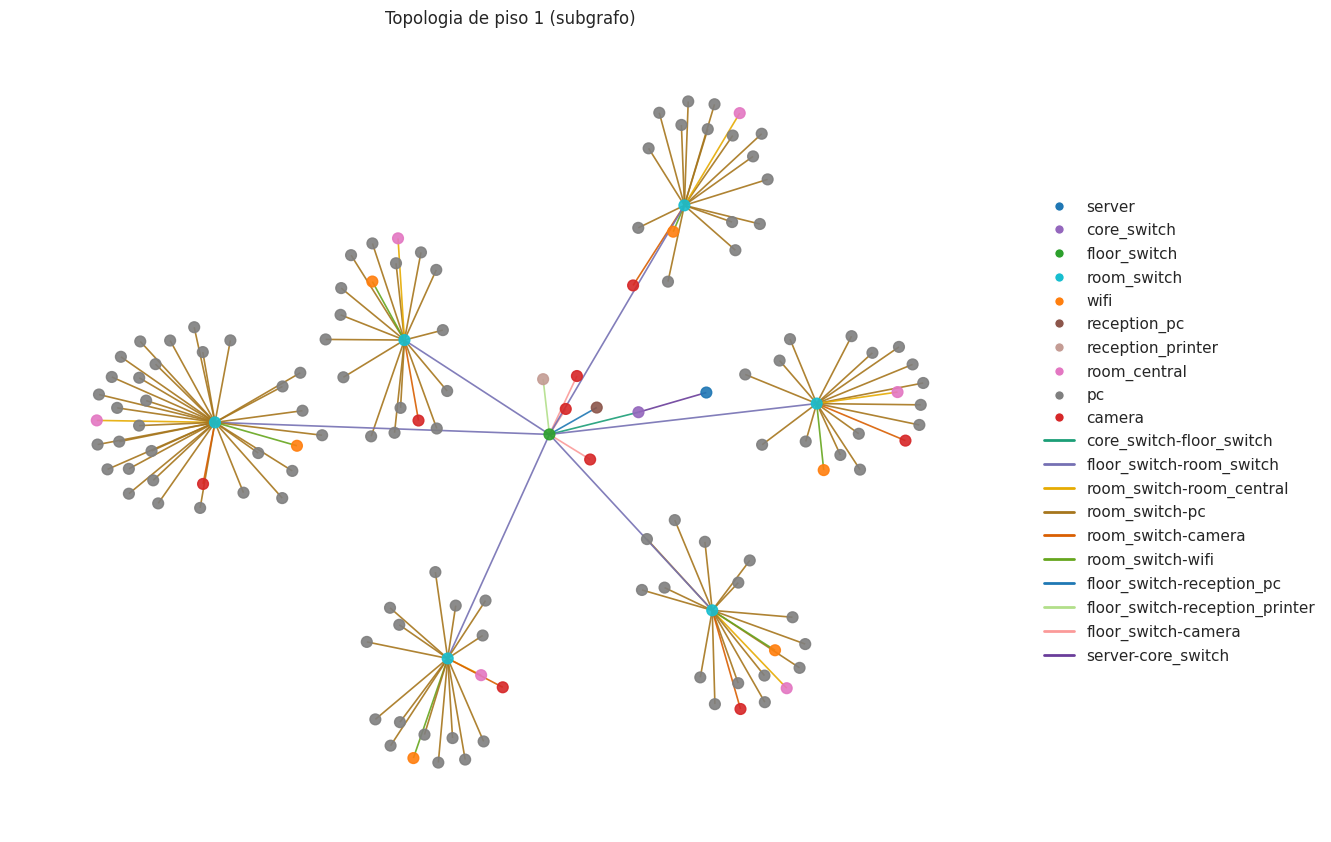

In [25]:
# Tomamos un subgrafo pequeño para que la visualización siga siendo legible.
nodes_floor1 = [n for n, d in G.nodes(data=True) if d.get("floor") == 1]
nodes_core = ["server_central", "core_switch", "floor1_switch"]
sub_nodes = set(nodes_floor1 + nodes_core)
H = G.subgraph(sub_nodes).copy()

# Colores por tipo de nodo para distinguir capas de la red.
node_colors_by_type = {
    "server": "#1f77b4",
    "core_switch": "#9467bd",
    "floor_switch": "#2ca02c",
    "room_switch": "#17becf",
    "wifi": "#ff7f0e",
    "reception_pc": "#8c564b",
    "reception_printer": "#c49c94",
    "room_central": "#e377c2",
    "pc": "#7f7f7f",
    "camera": "#d62728",
}

# Colores de aristas por relación estructural principal.
edge_colors_by_pair = {
    ("core_switch", "floor_switch"): "#1b9e77",
    ("floor_switch", "room_switch"): "#7570b3",
    ("room_switch", "room_central"): "#e6ab02",
    ("room_switch", "pc"): "#a6761d",
    ("room_switch", "camera"): "#d95f02",
    ("room_switch", "wifi"): "#66a61e",
    ("floor_switch", "reception_pc"): "#1f78b4",
    ("floor_switch", "reception_printer"): "#b2df8a",
    ("floor_switch", "camera"): "#fb9a99",
    ("server", "core_switch"): "#6a3d9a",
}

node_colors = []
for n in H.nodes():
    n_type = H.nodes[n].get("type")
    node_colors.append(node_colors_by_type.get(n_type, "#cccccc"))

edge_colors = []
for u, v in H.edges():
    u_type = H.nodes[u].get("type")
    v_type = H.nodes[v].get("type")
    pair = (u_type, v_type)
    rev_pair = (v_type, u_type)
    edge_colors.append(edge_colors_by_pair.get(pair, edge_colors_by_pair.get(rev_pair, "#bbbbbb")))

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42, k=0.2)
nx.draw(
    H, pos, node_size=60, with_labels=False, alpha=0.9,
    node_color=node_colors, edge_color=edge_colors, width=1.2
)
plt.title("Topologia de piso 1 (subgrafo)")

from matplotlib.lines import Line2D

# Leyendas separadas para nodos y enlaces.
node_legend = [
    Line2D([0], [0], marker="o", color="w", label=label,
           markerfacecolor=color, markersize=7)
    for label, color in node_colors_by_type.items()
]
edge_legend = [
    Line2D([0], [0], color=color, lw=2, label=f"{a}-{b}")
    for (a, b), color in edge_colors_by_pair.items()
]

plt.legend(handles=node_legend + edge_legend, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

## Tablas comparativas

Se comparan los escenarios por alcanzabilidad y longitud promedio de la ruta.

In [26]:
# Resumimos el comportamiento de BFS por escenario.
summary = (
    df_results.groupby("scenario")
    .agg(reachable_rate=("reachable", "mean"),
         avg_path_length=("path_length", "mean"),
         avg_visited=("visited", "mean"))
    .reset_index()
)
summary

,scenario,reachable_rate,avg_path_length,avg_visited
0,congestion,1.00,3.25,76.75
1,critico,0.50,2.50,6.50
2,normal,1.00,3.25,73.75
3,seguridad_alta,0.75,3.00,13.75


## Resultados obtenidos

Los resultados muestran que la alcanzabilidad cambia según los umbrales aplicados:

- En el escenario `normal`, todos los orígenes evaluados alcanzan el servidor central.
- En `seguridad_alta`, el PC de aula común no alcanza el servidor, mientras que el PC central de aula, el PC administrativo y el equipo de vigilancia sí lo alcanzan.
- En `critico`, el PC de aula común y el PC central de aula no alcanzan el servidor. El PC administrativo y el equipo de vigilancia sí mantienen una ruta válida.
- En `congestion`, todos los orígenes evaluados alcanzan el servidor central.

También se observa que las rutas de administración y vigilancia tienen menos saltos que las rutas desde aulas: vigilancia alcanza el servidor en 2 saltos, administración en 3 saltos y los equipos de aula en 4 saltos cuando las restricciones lo permiten.

## Análisis de resultados

Los resultados confirman que la conectividad no depende solo de la existencia física de enlaces, sino también de las condiciones exigidas a cada conexión. Cuando los umbrales son moderados, la mayoría de enlaces relevantes siguen siendo válidos y los dispositivos evaluados pueden llegar al servidor.

En `seguridad_alta`, los computadores comunes de aula pierden conectividad porque sus enlaces finales tienen menor nivel de seguridad o menor capacidad frente a los umbrales definidos. En `critico`, solo los dispositivos conectados mediante enlaces más robustos conservan una ruta válida, por eso administración y vigilancia siguen alcanzando el servidor mientras algunos dispositivos de aula quedan aislados.

El escenario `congestion` permite mayor latencia y menor ancho de banda, por lo que la alcanzabilidad se mantiene. Esto muestra que relajar ciertos criterios aumenta el subgrafo disponible para BFS, aunque no significa necesariamente que la red tenga mejores condiciones de operación.

## Comparación gráfica

Se muestra un gráfico de barras con el porcentaje de orígenes alcanzables por escenario.

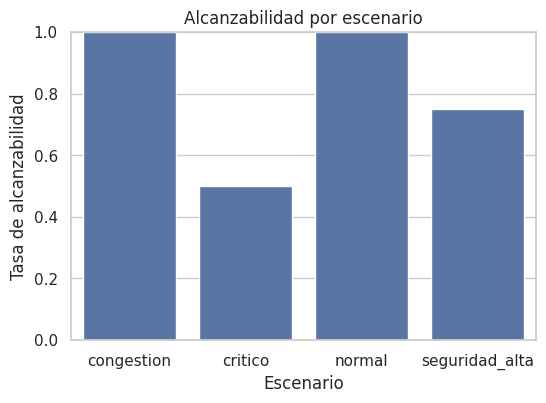

In [27]:
# Barras simples para comparar la proporción de orígenes alcanzables.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x="scenario", y="reachable_rate")
plt.ylim(0, 1)
plt.title("Alcanzabilidad por escenario")
plt.ylabel("Tasa de alcanzabilidad")
plt.xlabel("Escenario")
plt.show()

## Conclusiones

Los experimentos realizados ofrecen una lectura clara: en condiciones normales y bajo congestión los orígenes seleccionados mantienen conectividad completa hacia el servidor central, mientras que al endurecer las políticas de seguridad aparecen desconexiones relevantes en los extremos de usuario.

En detalle, tanto el escenario `normal` como `congestion` mostraron alcanzabilidad completa para los cuatro orígenes probados, con rutas típicas de 2 a 4 saltos (las cámaras de vigilancia son las más cercanas, los PCs de aula los más alejados). Cuando elevamos el umbral de seguridad (`seguridad_alta`), uno de los PCs de aula quedó incomunicado; al exigir seguridad máxima (`critico`) la desconexión se vuelve aún más severa y afectan dos orígenes.

Estos resultados sugieren un trade‑off intuitivo y operativo: endurecer `s_min` protege la red pero reduce la superficie alcanzable desde dispositivos con enlaces menos robustos (por ejemplo puntos de acceso Wi‑Fi o enlaces de usuario con security=3). Así, los valores agregados de exploración del grafo aumentan en escenarios permisivos (decenas de nodos explorados de media) y se reducen drásticamente cuando el filtrado es estricto, lo que refleja una menor disponibilidad efectiva para ciertos segmentos.

Desde una perspectiva práctica, conviene priorizar la elevación de seguridad en los enlaces de acceso más críticos o aplicar perfiles que preserven acceso a servicios administrativos y de vigilancia mientras se endurecen otras zonas. Además, estos resultados motivan validar el modelo con datos reales del CENTIC y ampliar las pruebas (más orígenes, escenarios de fallo, análisis temporal) para convertir las observaciones en acciones de red concretas.

En resumen: la metodología (BFS con filtrado por atributos) es útil para exponer cómo las políticas de seguridad y los umbrales de recursos impactan la conectividad; los números muestran que la seguridad es el factor que más influencia la pérdida de conectividad en los orígenes de aula, por lo que las intervenciones deberían enfocarse en reforzar esos enlaces o en diseñar perfiles que mantengan la disponibilidad de los servicios críticos.

## Trabajo futuro

A continuación se proponen oportunidades de mejora y extensiones para trabajos futuros, orientadas a aumentar el realismo, la seguridad y la robustez del modelo de la red del CENTIC.

- Ampliar el modelo a un grafo dirigido para soportar políticas de control de acceso y rutas asimétricas.
- Introducir niveles de prioridad y perfiles por tipo de dispositivo (por ejemplo: cámaras, servidores, PCs), y modelar reglas de enrutamiento preferente.
- Calibrar el modelo con datos reales de tráfico y mediciones del CENTIC para ajustar los umbrales de ancho de banda y latencia.
- Simular escenarios de fallo de enlaces, switches o nodos críticos para analizar resiliencia y proponer mejoras topológicas.
- Incorporar análisis probabilístico de latencia y disponibilidad (modelos estocásticos y variabilidad temporal).
- Añadir visualizaciones interactivas (por ejemplo con Plotly/Dash) para explorar rutas, subgrafos y métricas dinámicamente.
- Automatizar la generación y evaluación de escenarios (barridos de umbrales, combinación de restricciones y comparación de métricas).


## Bibliografía

- Rosen, K. H. *Discrete Mathematics and Its Applications*.
- Gross, J. L. y Yellen, J. *Graph Theory and Its Applications*.
- Material de clase de Matemáticas Discretas.
- Documentación de NetworkX: https://networkx.org/documentation/stable/
- Repositorio del proyecto: https://github.com/DanielJoaco/centic-bfs
- Notebook en Google Colab: https://colab.research.google.com/github/DanielJoaco/centic-bfs/blob/main/centic_bfs.ipynb

In [ ]:
# Celda para regenerar las figuras desde los CSV actualizados.
# La función que genera las figuras está definida abajo; la llamada a la función
# permanece comentada para que se ejecute manualmente cuando se desee.

df = pd.read_csv('figures/resultados_bfs.csv')
summary = pd.read_csv('figures/resumen_escenarios.csv')

def generate_figures():
    sns.set_theme(style='whitegrid')
    os.makedirs('figures', exist_ok=True)

    # Alcanzabilidad por escenario
    plt.figure(figsize=(6, 4))
    sns.barplot(data=summary, x='scenario', y='reachable_rate')
    plt.ylim(0, 1)
    plt.title('Alcanzabilidad por escenario')
    plt.ylabel('Tasa de alcanzabilidad')
    plt.xlabel('Escenario')
    plt.tight_layout()
    plt.savefig('figures/alcanzabilidad_escenarios.png', dpi=150)
    plt.close()

    # Longitud de ruta por origen y escenario
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x='origin', y='path_length', hue='scenario')
    plt.title('Longitud de ruta por origen y escenario')
    plt.ylabel('Saltos')
    plt.xlabel('Origen')
    plt.legend(title='Escenario', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('figures/path_length_origen.png', dpi=150)
    plt.close()

    print('Figuras guardadas en el directorio figures/')

# Para regenerar las figuras, descomente la siguiente línea y ejecute la celda manualmente:
#generate_figures()

Figuras guardadas en el directorio figures/
